# 03 — Baseline Models

**Insurance Claim Fraud Detection & Action Recommendation System**

This notebook establishes the honest, reproducible reference bar that the
tuned XGBoost/LightGBM candidates in Notebook 04 must beat, and builds the
shared evaluation harness every later modelling notebook reuses. Two simple,
established models are trained — Logistic Regression and Balanced Random
Forest — with imbalance handling but **no hyperparameter search**.

**What this notebook does:**
1. Loads Notebook 02's saved primary train/val splits and fitted
   preprocessing pipeline — does not re-split, re-clean, or refit anything
2. Applies the already-fitted pipeline (`.transform()` only)
3. Trains two baselines with built-in imbalance handling, no tuning
4. Builds a reusable evaluation harness (metrics, CV runner, results logger)
5. Cross-validates on training data and scores once on validation
6. Produces a results table, PR curves, confusion matrices, and appends to
   the shared `experiments.csv`
7. Runs sanity checks — including a leakage tripwire on suspiciously high
   PR-AUC

**Explicitly out of scope here:** hyperparameter tuning / Optuna,
SMOTE/SMOTENC, refitting preprocessing, calibration, threshold selection, and
anything involving the test set — that set is opened once, later, in
Notebook 06.

## 1. Environment & Google Drive Setup

Same conventions as Notebooks 01-02: everything derives from one
`PROJECT_ROOT`, Drive is mounted first, and every expected input is verified
to exist before this notebook does any work.

In [20]:
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, confusion_matrix, f1_score,
    matthews_corrcoef, precision_recall_curve, precision_score, recall_score, roc_auc_score, brier_score_loss
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.ensemble import BalancedRandomForestClassifier
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

TARGET_COL = "FraudFound_P"
RANDOM_STATE = 42

# Same fixed categorical palette as Notebook 01, kept self-contained here so this
# notebook doesn't depend on another notebook's kernel state.
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}

saved_files = []  # every artifact written to Drive is recorded here for the final recap
print("Libraries imported.")

Libraries imported.


### Mount Google Drive

In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "This notebook is designed to run in Google Colab with the team's shared "
        "Drive mounted. `google.colab` is not available in this environment - open "
        "the notebook in Colab and re-run."
    ) from exc

Mounted at /content/drive


### Define project paths

Same layout as Notebooks 01-02, plus a `results/figures/baseline/` figures
directory for this notebook's outputs and the shared, project-wide
`results/experiments.csv` log.

In [31]:
PROJECT_ROOT = Path("/content/drive/MyDrive/InsuranceFraudProject")

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_BASELINE_DIR = RESULTS_DIR / "figures" / "baseline"
MODELS_DIR = PROJECT_ROOT / "models"

TRAIN_PATH = DATA_PROCESSED_DIR / "train.parquet"
VAL_PATH = DATA_PROCESSED_DIR / "val.parquet"
PIPELINE_PATH = MODELS_DIR / "preprocessing_pipeline.joblib"
EXPERIMENTS_CSV_PATH = RESULTS_DIR / "experiments.csv"

FIGURES_BASELINE_DIR.mkdir(parents=True, exist_ok=True)

print("Project configuration")
print("-" * 60)
print(f"PROJECT_ROOT           : {PROJECT_ROOT}")
print(f"TRAIN_PATH              : {TRAIN_PATH}")
print(f"VAL_PATH                : {VAL_PATH}")
print(f"PIPELINE_PATH           : {PIPELINE_PATH}")
print(f"FIGURES_BASELINE_DIR    : {FIGURES_BASELINE_DIR}")
print(f"EXPERIMENTS_CSV_PATH    : {EXPERIMENTS_CSV_PATH}")
print("\nNote: test.parquet is intentionally never referenced in this notebook.")

Project configuration
------------------------------------------------------------
PROJECT_ROOT           : /content/drive/MyDrive/InsuranceFraudProject
TRAIN_PATH              : /content/drive/MyDrive/InsuranceFraudProject/data/processed/train.parquet
VAL_PATH                : /content/drive/MyDrive/InsuranceFraudProject/data/processed/val.parquet
PIPELINE_PATH           : /content/drive/MyDrive/InsuranceFraudProject/models/preprocessing_pipeline.joblib
FIGURES_BASELINE_DIR    : /content/drive/MyDrive/InsuranceFraudProject/results/figures/baseline
EXPERIMENTS_CSV_PATH    : /content/drive/MyDrive/InsuranceFraudProject/results/experiments.csv

Note: test.parquet is intentionally never referenced in this notebook.


### Verify expected inputs exist

Three inputs are required, all produced by Notebook 02: the training split,
the validation split, and the fitted preprocessing pipeline. Fail clearly,
before doing any work, if any is missing.

In [32]:
missing_inputs = []
for label, path in [("train.parquet", TRAIN_PATH), ("val.parquet", VAL_PATH),
                     ("preprocessing_pipeline.joblib", PIPELINE_PATH)]:
    if not path.exists():
        missing_inputs.append((label, path))

if missing_inputs:
    details = "\n".join(f"  - {label}: {path}" for label, path in missing_inputs)
    raise FileNotFoundError(
        f"Missing required input(s) from Notebook 02:\n{details}\n\n"
        "Run 02_preprocessing_and_splitting.ipynb first - this notebook loads its "
        "saved splits and fitted pipeline rather than recreating them."
    )

print("Found train.parquet, val.parquet, and the fitted preprocessing pipeline.")

Found train.parquet, val.parquet, and the fitted preprocessing pipeline.


## 2. Load Notebook 02's Outputs

Loaded, not recreated: the primary train/val splits and the pipeline fit on
training data only. **`test.parquet` is never loaded here** — baselines are
compared on validation; the locked test set is opened once, later, in
Notebook 06.

In [33]:
train_df = pd.read_parquet(TRAIN_PATH)
val_df = pd.read_parquet(VAL_PATH)
preprocessing_pipeline = joblib.load(PIPELINE_PATH)

print(f"train_df: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"val_df:   {val_df.shape[0]:,} rows x {val_df.shape[1]} columns")
print(f"train fraud rate: {train_df[TARGET_COL].mean() * 100:.2f}%")
print(f"val fraud rate:   {val_df[TARGET_COL].mean() * 100:.2f}%")

train_df: 10,793 rows x 30 columns
val_df:   2,313 rows x 30 columns
train fraud rate: 5.99%
val fraud rate:   6.01%


### Note on Probability Calibration

Class-weighted and tree-based models (such as the Logistic Regression with `class_weight` and Balanced Random Forest used here) often produce probabilities that are not well-calibrated. This means that a predicted probability (e.g., 0.7 for fraud) might not accurately reflect the true likelihood of the event. While this doesn't impact ranking metrics like PR-AUC or ROC-AUC, it's critical for downstream applications where the absolute probability matters for decision-making (e.g., setting risk thresholds).

This is why a dedicated calibration step will be explored in Notebook 05, to ensure that the predicted probabilities are accurate reflections of the true event likelihoods.

## 3. Apply the Fitted Preprocessing Pipeline

The pipeline was fit on the training split in Notebook 02 and is applied here
with `.transform()` only — `.fit()` and `.fit_transform()` are never called
on anything in this notebook. This also applies to cross-validation below:
CV folds are drawn from the already-encoded training matrix rather than
re-fitting the (entirely unsupervised — imputation median, one-hot
categories) preprocessing per fold. That's a deliberate simplification, not
an oversight: those transforms use no target information, so reusing a
train-fit pipeline across folds risks only a mild distributional leak (e.g.
the imputation median reflects all of training, not just each fold's 80%),
never a target-label leak. Refitting preprocessing at all is out of scope for
this notebook by design (Notebook 02 owns that contract).

## 4. Baseline Models

**Fair-comparison rule:** these baselines *do* get imbalance handling, but
through mechanisms built into the algorithm itself, not an external
resampling step:

- **Logistic Regression** uses `class_weight="balanced"` — cost-sensitive
  reweighting of the loss function.
- **Balanced Random Forest** (imbalanced-learn) balances each tree's
  bootstrap sample internally by design — its imbalance handling is native
  to the algorithm, not a separate step this notebook applies.

Neither gets SMOTE/SMOTENC or any other explicit external resampling applied
to the training set, and neither gets a hyperparameter search. That external
resampling comparison is Notebook 04's experiment (tuned, inside CV folds);
running it here would blur the reference point this notebook exists to
provide. An *unbalanced* baseline would predict "no fraud" almost everywhere
and catch ~1% of fraud cases — technically high accuracy, practically
useless, and not a fair opponent for Notebook 04's tuned candidates. All
hyperparameters below are fixed, reasonable values — not searched or tuned.

**One more per-model difference, not an imbalance mechanism:** Logistic
Regression is wrapped with a `StandardScaler` ahead of the classifier.
Notebook 02's pipeline deliberately does not scale anything (tree-based
models don't need it, and scaling is arguably a model-fitting concern rather
than a shared preprocessing one) — so unscaled, wildly-different-magnitude
inputs (a 0/1 dummy next to `Year` in the 1990s) leave `lbfgs` poorly
conditioned and slow/unable to converge. Wrapping the scaler and classifier
in one `Pipeline` keeps this a model-internal detail: it's refit on each CV
fold's training data only via the same `clone()` + `.fit()` calls everything
else uses, so it adds no leakage and needs no special-casing in the
evaluation harness below. Balanced Random Forest is scale-invariant and is
left as-is.

In [34]:
BASELINE_MODELS = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            class_weight="balanced", max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE,
        )),
    ]),
    "Balanced Random Forest": BalancedRandomForestClassifier(
        n_estimators=300, sampling_strategy="all", replacement=True,
        bootstrap=True, random_state=RANDOM_STATE, n_jobs=-1,
    ),
}

BALANCING_STRATEGY = {
    "Logistic Regression": "class_weight=balanced (cost-sensitive reweighting)",
    "Balanced Random Forest": "balanced bootstrap sampling per tree (built-in)",
}


def summarize_params(model, keys: list) -> str:
    """Compact 'key=value, ...' string of selected hyperparameters, for the experiment
    log. Works for a bare estimator or a Pipeline (keys like 'logreg__max_iter') -
    the step prefix is stripped for readability."""
    params = model.get_params()
    return ", ".join(f"{k.split('__')[-1]}={params[k]}" for k in keys if k in params)


PARAMS_SUMMARY = {
    "Logistic Regression": summarize_params(
        BASELINE_MODELS["Logistic Regression"],
        ["scaler", "logreg__class_weight", "logreg__max_iter", "logreg__solver"]),
    "Balanced Random Forest": summarize_params(
        BASELINE_MODELS["Balanced Random Forest"],
        ["n_estimators", "sampling_strategy", "replacement", "bootstrap"]),
}

for name, summary in PARAMS_SUMMARY.items():
    print(f"{name}: {summary}")

Logistic Regression: scaler=StandardScaler(), class_weight=balanced, max_iter=2000, solver=lbfgs
Balanced Random Forest: n_estimators=300, sampling_strategy=all, replacement=True, bootstrap=True


## 5. Evaluation Harness (Reusable)

These functions are written to be reused unchanged in Notebook 04 — a fair
baseline-vs-candidate comparison requires measuring both with the exact same
logic.

**Why PR-AUC (average precision), not accuracy:** at ~6% fraud prevalence, a
model that predicts "legitimate" for every claim scores ~94% accuracy while
catching zero fraud. Accuracy is not reported as a headline metric anywhere
in this project for that reason. PR-AUC summarizes the precision/recall
trade-off across all thresholds and is far more informative on this kind of
imbalance; Recall, Precision, Macro-F1, MCC, and ROC-AUC are reported
alongside it as secondary context.

In [35]:
def compute_fraud_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> dict:
    """Metrics for the fraud (positive) class, at whatever threshold produced y_pred.

    PR-AUC and ROC-AUC use y_proba (threshold-independent); the rest use y_pred
    (the model's default 0.5 cutoff here - no threshold tuning happens in this
    notebook, see Notebook 05).
    """
    return {
        "pr_auc": average_precision_score(y_true, y_proba),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba)
    }


def cross_validate_model(model, X: np.ndarray, y: np.ndarray, n_splits: int = 5,
                          random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """Stratified k-fold CV: clone + refit `model` per fold, score on that fold's
    holdout. Returns one row of metrics per fold; callers take mean/std.
    Cloning per fold guarantees no fitted state leaks across folds.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []
    for fold_idx, (fold_train_idx, fold_holdout_idx) in enumerate(skf.split(X, y)):
        fold_model = clone(model)
        fold_model.fit(X[fold_train_idx], y[fold_train_idx])
        y_pred = fold_model.predict(X[fold_holdout_idx])
        y_proba = fold_model.predict_proba(X[fold_holdout_idx])[:, 1]
        row = compute_fraud_metrics(y[fold_holdout_idx], y_pred, y_proba)
        row["fold"] = fold_idx
        row["fold_fraud_rate"] = y[fold_holdout_idx].mean()
        fold_rows.append(row)
    return pd.DataFrame(fold_rows)


def summarize_cv(cv_results: pd.DataFrame) -> dict:
    """Collapse per-fold CV metrics into mean/std, keyed like 'pr_auc_mean'/'pr_auc_std'."""
    metric_cols = [c for c in cv_results.columns if c not in ("fold", "fold_fraud_rate")]
    summary = {}
    for col in metric_cols:
        summary[f"{col}_mean"] = cv_results[col].mean()
        summary[f"{col}_std"] = cv_results[col].std()
    return summary


def fit_and_evaluate(model, X_train_: np.ndarray, y_train_: np.ndarray,
                      X_eval: np.ndarray, y_eval: np.ndarray) -> dict:
    """Fit a fresh clone of `model` on the full training data, evaluate on X_eval/y_eval.
    Returns the fitted model and predictions alongside metrics, for reuse in plotting.
    """
    fitted = clone(model)
    fitted.fit(X_train_, y_train_)
    y_pred = fitted.predict(X_eval)
    y_proba = fitted.predict_proba(X_eval)[:, 1]
    return {
        "model": fitted, "y_pred": y_pred, "y_proba": y_proba,
        "metrics": compute_fraud_metrics(y_eval, y_pred, y_proba),
    }


def log_experiment(row: dict, path: Path) -> None:
    """Append one experiment row to the shared experiments.csv, creating it with a
    header if it doesn't exist yet. This is a full audit trail - re-running this
    notebook appends new rows rather than overwriting prior ones."""
    new_row_df = pd.DataFrame([row])
    combined = pd.concat([pd.read_csv(path), new_row_df], ignore_index=True) if path.exists() else new_row_df
    combined.to_csv(path, index=False)
    print(f"Logged experiment '{row['model']}' -> {path}")


print("Evaluation harness defined: compute_fraud_metrics, cross_validate_model, "
      "summarize_cv, fit_and_evaluate, log_experiment.")

Evaluation harness defined: compute_fraud_metrics, cross_validate_model, summarize_cv, fit_and_evaluate, log_experiment.


## 6. Cross-Validation + Validation-Set Results

Each baseline is evaluated two ways: 5-fold stratified CV on the training
data (a stable estimate with mean ± std, ~6% fraud preserved per fold), and a
single fit-on-full-train / score-on-validation number (the comparable figure
used for the results table, the experiment log, and the figures below).

In [36]:
baseline_results = {}

for model_name, model in BASELINE_MODELS.items():
    cv_raw = cross_validate_model(model, X_train, y_train, n_splits=5, random_state=RANDOM_STATE)
    cv_summary = summarize_cv(cv_raw)
    val_result = fit_and_evaluate(model, X_train, y_train, X_val, y_val)

    baseline_results[model_name] = {
        "cv_raw": cv_raw, "cv_summary": cv_summary,
        "model": val_result["model"], "y_pred": val_result["y_pred"],
        "y_proba": val_result["y_proba"], "val_metrics": val_result["metrics"],
    }

    print(f"\n{model_name}")
    print(f"  CV  PR-AUC = {cv_summary['pr_auc_mean']:.3f} +/- {cv_summary['pr_auc_std']:.3f}")
    print(f"  Val PR-AUC = {val_result['metrics']['pr_auc']:.3f}")
    print(f"  CV Brier Score = {cv_summary['brier_score_mean']:.3f} +/- {cv_summary['brier_score_std']:.3f}")
    print(f"  Val Brier Score = {val_result['metrics']['brier_score']:.3f}")


Logistic Regression
  CV  PR-AUC = 0.159 +/- 0.024
  Val PR-AUC = 0.140
  CV Brier Score = 0.190 +/- 0.010
  Val Brier Score = 0.198

Balanced Random Forest
  CV  PR-AUC = 0.195 +/- 0.017
  Val PR-AUC = 0.204
  CV Brier Score = 0.152 +/- 0.007
  Val Brier Score = 0.156


## 7. Results Table

Sorted by validation PR-AUC — the single comparable number used for
model-to-model comparison. CV mean ± std is shown alongside as a stability
check: a model with a strong validation score but a wide CV std is a less
trustworthy result than one with both.

**No-skill reference:** a model with zero skill (random ranking) scores a
PR-AUC equal to the positive-class prevalence — here, the validation fraud
rate. Every PR-AUC below should be read relative to that floor, not to zero.
**Published reference (context only, not a pass/fail gate):** other work on
this exact dataset has reported PR-AUC around ~0.16; methodology differences
(features, preprocessing, model family) make an exact comparison imprecise,
so this is a sanity anchor, not a target baselines are required to hit.

In [37]:
no_skill_pr_auc = float(y_val.mean())
REFERENCE_PR_AUC = 0.16  # published reference point on this dataset - context only

results_rows = []
for model_name, result in baseline_results.items():
    row = {"model": model_name, "balancing_strategy": BALANCING_STRATEGY[model_name]}
    row.update({f"cv_{k}": v for k, v in result["cv_summary"].items()})
    row.update({f"val_{k}": v for k, v in result["val_metrics"].items()})
    results_rows.append(row)

results_df = pd.DataFrame(results_rows).sort_values("val_pr_auc", ascending=False).reset_index(drop=True)


def fmt(mean: float, std: float) -> str:
    return f"{mean:.3f} +/- {std:.3f}"


display_table = pd.DataFrame({
    "model": results_df["model"],
    "CV PR-AUC": [fmt(m, s) for m, s in zip(results_df["cv_pr_auc_mean"], results_df["cv_pr_auc_std"])],
    "Val PR-AUC": results_df["val_pr_auc"].round(3),
    "CV Recall": [fmt(m, s) for m, s in zip(results_df["cv_recall_mean"], results_df["cv_recall_std"])],
    "Val Recall": results_df["val_recall"].round(3),
    "CV Precision": [fmt(m, s) for m, s in zip(results_df["cv_precision_mean"], results_df["cv_precision_std"])],
    "Val Precision": results_df["val_precision"].round(3),
    "CV Macro-F1": [fmt(m, s) for m, s in zip(results_df["cv_macro_f1_mean"], results_df["cv_macro_f1_std"])],
    "Val Macro-F1": results_df["val_macro_f1"].round(3),
    "CV MCC": [fmt(m, s) for m, s in zip(results_df["cv_mcc_mean"], results_df["cv_mcc_std"])],
    "Val MCC": results_df["val_mcc"].round(3),
    "CV ROC-AUC": [fmt(m, s) for m, s in zip(results_df["cv_roc_auc_mean"], results_df["cv_roc_auc_std"])],
    "Val ROC-AUC": results_df["val_roc_auc"].round(3),
    "CV Brier Score": [fmt(m, s) for m, s in zip(results_df["cv_brier_score_mean"], results_df["cv_brier_score_std"])],
    "Val Brier Score": results_df["val_brier_score"].round(3)
})

print(f"No-skill PR-AUC (validation fraud prevalence): {no_skill_pr_auc:.3f}")
print(f"Published reference PR-AUC (context only):     ~{REFERENCE_PR_AUC}")
display(display_table)

No-skill PR-AUC (validation fraud prevalence): 0.060
Published reference PR-AUC (context only):     ~0.16


,model,CV PR-AUC,Val PR-AUC,CV Recall,Val Recall,CV Precision,Val Precision,CV Macro-F1,Val Macro-F1,CV MCC,Val MCC,CV ROC-AUC,Val ROC-AUC,CV Brier Score,Val Brier Score
0,Balanced Random Forest,0.195 +/- 0.017,0.204,0.845 +/- 0.035,0.842,0.140 +/- 0.008,0.139,0.518 +/- 0.014,0.517,0.254 +/- 0.017,0.251,0.821 +/- 0.015,0.816,0.152 +/- 0.007,0.156
1,Logistic Regression,0.159 +/- 0.024,0.140,0.814 +/- 0.023,0.871,0.129 +/- 0.007,0.131,0.502 +/- 0.013,0.499,0.227 +/- 0.015,0.244,0.788 +/- 0.017,0.784,0.190 +/- 0.010,0.198


## 8. Experiment Log

Every baseline run is appended to `results/experiments.csv` — the project's
evidence trail for model selection. Columns beyond the required set
(`cv_pr_auc_mean`/`cv_pr_auc_std`, `eval_split`) are additive context for
later audit; Notebook 04 should match this column schema when logging its
own runs.

In [38]:
for model_name, result in baseline_results.items():
    m = result["val_metrics"]
    row = {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "seed": RANDOM_STATE,
        "model": model_name,
        "balancing_strategy": BALANCING_STRATEGY[model_name],
        "params_summary": PARAMS_SUMMARY[model_name],
        "eval_split": "validation",
        "pr_auc": m["pr_auc"],
        "recall": m["recall"],
        "precision": m["precision"],
        "macro_f1": m["macro_f1"],
        "mcc": m["mcc"],
        "roc_auc": m["roc_auc"],
        "brier_score": m["brier_score"],
        "cv_pr_auc_mean": result["cv_summary"]["pr_auc_mean"],
        "cv_pr_auc_std": result["cv_summary"]["pr_auc_std"],
        "cv_brier_score_mean": result["cv_summary"]["brier_score_mean"],
        "cv_brier_score_std": result["cv_summary"]["brier_score_std"],
    }
    log_experiment(row, EXPERIMENTS_CSV_PATH)

saved_files.append(EXPERIMENTS_CSV_PATH)

Logged experiment 'Logistic Regression' -> /content/drive/MyDrive/InsuranceFraudProject/results/experiments.csv
Logged experiment 'Balanced Random Forest' -> /content/drive/MyDrive/InsuranceFraudProject/results/experiments.csv


## 9. Figures

A combined precision-recall curve (both baselines plus the no-skill
reference line) and default-threshold confusion matrices. **The confusion
matrices use the default 0.5 probability cutoff and are illustrative only**
— no threshold tuning happens in this notebook; that's Notebook 05, on
validation, using calibrated probabilities.

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/baseline/pr_curves_baseline.png  (Logistic Regression vs. Balanced Random Forest)


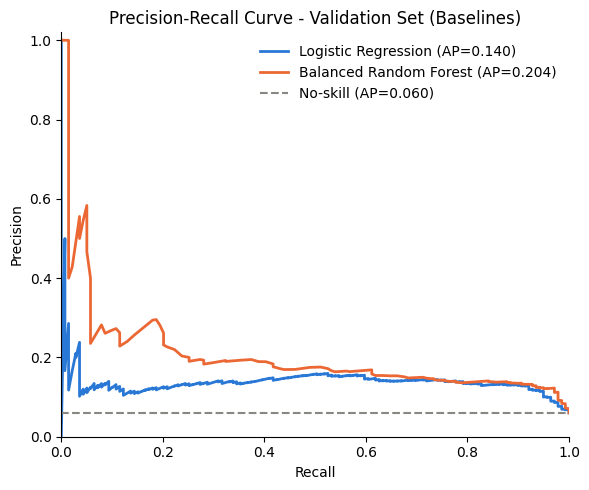

In [39]:
def save_figure(fig, filename: str, note: str = "") -> Path:
    """Save a figure to the baseline figures directory, record it, and print the path."""
    out_path = FIGURES_BASELINE_DIR / filename
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    saved_files.append(out_path)
    print(f"Saved figure -> {out_path}" + (f"  ({note})" if note else ""))
    return out_path


MODEL_COLORS = {
    "Logistic Regression": PALETTE["blue"],
    "Balanced Random Forest": PALETTE["orange"],
}

fig, ax = plt.subplots(figsize=(6, 5))
for model_name, result in baseline_results.items():
    precision, recall, _ = precision_recall_curve(y_val, result["y_proba"])
    ap = result["val_metrics"]["pr_auc"]
    ax.plot(recall, precision, color=MODEL_COLORS[model_name], linewidth=2,
            label=f"{model_name} (AP={ap:.3f})")

ax.axhline(no_skill_pr_auc, color="#898781", linestyle="--", linewidth=1.5,
           label=f"No-skill (AP={no_skill_pr_auc:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Validation Set (Baselines)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="upper right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

save_figure(fig, "pr_curves_baseline.png", note="Logistic Regression vs. Balanced Random Forest")
plt.show()

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/baseline/confusion_matrices_baseline_default_threshold.png


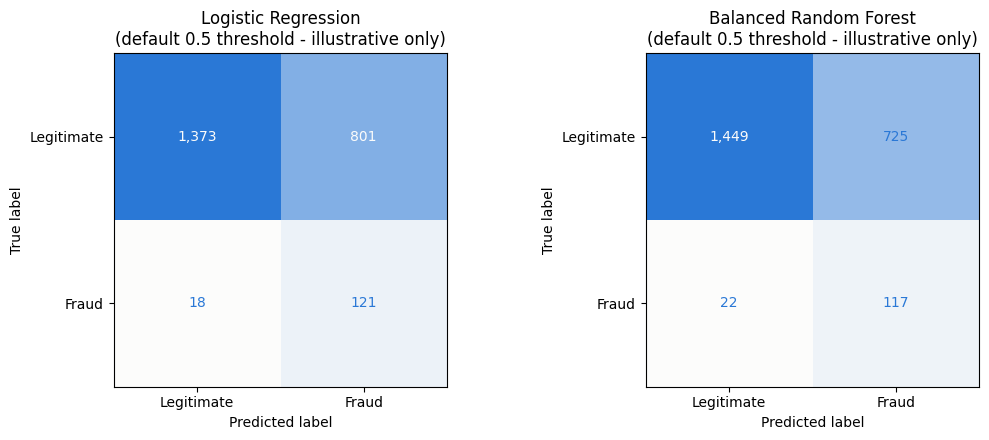

In [40]:
blue_sequential = LinearSegmentedColormap.from_list("blue_sequential", ["#fcfcfb", PALETTE["blue"]])

fig, axes = plt.subplots(1, len(baseline_results), figsize=(5.5 * len(baseline_results), 4.5))
axes = np.atleast_1d(axes)

for ax, (model_name, result) in zip(axes, baseline_results.items()):
    cm = confusion_matrix(y_val, result["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
    disp.plot(ax=ax, cmap=blue_sequential, colorbar=False, values_format=",")
    ax.set_title(f"{model_name}\n(default 0.5 threshold - illustrative only)")

fig.tight_layout()
save_figure(fig, "confusion_matrices_baseline_default_threshold.png")
plt.show()

## 10. Sanity Checks

These are not optional prints — each targets a specific way this notebook
could go wrong. **The PR-AUC ceiling check is the leakage tripwire**: an
untuned baseline scoring anywhere near 0.9 PR-AUC on this dataset is a sign
something upstream is leaking, not a sign of a great model — that must be
investigated before trusting anything downstream.

### Baselines beat no-skill, stay under the leakage ceiling, and are meaningfully balanced

In [41]:
LEAKAGE_CEILING_PR_AUC = 0.90
MIN_SANE_RECALL = 0.05  # "meaningfully more than the ~1% an unbalanced model gives"

for model_name, result in baseline_results.items():
    m = result["val_metrics"]
    assert m["recall"] > MIN_SANE_RECALL, (
        f"{model_name}: recall {m['recall']:.3f} looks unbalanced (close to the ~1% an "
        "unweighted model gives) - check the class_weight/balancing configuration."
    )
    assert m["pr_auc"] > no_skill_pr_auc, (
        f"{model_name}: PR-AUC {m['pr_auc']:.3f} does not beat the no-skill baseline "
        f"{no_skill_pr_auc:.3f}."
    )
    assert m["pr_auc"] < LEAKAGE_CEILING_PR_AUC, (
        f"{model_name}: PR-AUC {m['pr_auc']:.3f} is suspiciously high for an untuned "
        "baseline - stop and check for leakage before proceeding."
    )
print(f"PASSED: both baselines beat no-skill ({no_skill_pr_auc:.3f}), stay under the "
      f"{LEAKAGE_CEILING_PR_AUC} leakage ceiling, and clear the {MIN_SANE_RECALL} recall floor.")

PASSED: both baselines beat no-skill (0.060), stay under the 0.9 leakage ceiling, and clear the 0.05 recall floor.


### Neither model's fitted state changed when scoring validation

In [42]:
def snapshot_fitted_state(model) -> np.ndarray:
    """Grab one representative fitted attribute, to detect an accidental refit later.
    Unwraps a Pipeline to its final estimator first (e.g. the scaled Logistic
    Regression baseline) - a Pipeline does not expose the last step's attributes
    directly."""
    target = model.steps[-1][1] if hasattr(model, "steps") else model
    if hasattr(target, "coef_"):
        return target.coef_.copy()
    if hasattr(target, "feature_importances_"):
        return target.feature_importances_.copy()
    raise AttributeError(f"Don't know how to snapshot fitted state for {type(target).__name__}")


for model_name, result in baseline_results.items():
    fitted_model = result["model"]
    before = snapshot_fitted_state(fitted_model)
    _ = fitted_model.predict(X_val)
    _ = fitted_model.predict_proba(X_val)
    after = snapshot_fitted_state(fitted_model)
    assert np.array_equal(before, after), (
        f"{model_name}: fitted state changed after scoring validation - it must never be refit."
    )
print("PASSED: neither baseline's fitted state changed when scoring the validation set.")

PASSED: neither baseline's fitted state changed when scoring the validation set.


### Stratified folds preserved the training fraud rate

In [43]:
FOLD_FRAUD_RATE_TOLERANCE_PCT = 2.0
overall_train_fraud_rate = float(y_train.mean()) * 100

for model_name, result in baseline_results.items():
    fold_rates = result["cv_raw"]["fold_fraud_rate"] * 100
    max_drift = (fold_rates - overall_train_fraud_rate).abs().max()
    assert max_drift < FOLD_FRAUD_RATE_TOLERANCE_PCT, (
        f"{model_name}: a CV fold's fraud rate drifted {max_drift:.2f}pt from the "
        f"{overall_train_fraud_rate:.2f}% training rate - stratification may have failed."
    )
print(f"PASSED: every CV fold stayed within {FOLD_FRAUD_RATE_TOLERANCE_PCT}pt of the "
      f"{overall_train_fraud_rate:.2f}% training fraud rate, for both models.")

PASSED: every CV fold stayed within 2.0pt of the 5.99% training fraud rate, for both models.


### The test set was never touched

In [44]:
assert "test_df" not in dir() and "X_test" not in dir() and "y_test" not in dir(), (
    "Test set must not be loaded or referenced in this notebook - it is opened once, "
    "later, in Notebook 06."
)
print("PASSED: test.parquet / test_df / X_test / y_test are absent from this notebook's namespace.")

PASSED: test.parquet / test_df / X_test / y_test are absent from this notebook's namespace.


All sanity checks passed. If the leakage-ceiling check ever fails on a
re-run, treat it as a hard stop: do not proceed to Notebook 04 until the
cause is found (a likely culprit is a column that encodes post-outcome
information leaking through the pipeline).

## Baseline Summary

In [45]:
best_model_name = results_df.iloc[0]["model"]
best_pr_auc = results_df.iloc[0]["val_pr_auc"]

summary_md = f"""
**Models trained:** Logistic Regression (`class_weight=balanced`) and Balanced
Random Forest (native balanced bootstrap sampling) - both untuned, both evaluated
identically via the reusable harness in Section 5.

**Reference point for Notebook 04:** `{best_model_name}` leads on validation PR-AUC
at {best_pr_auc:.3f}, against a no-skill floor of {no_skill_pr_auc:.3f} and a
published (context-only) reference of ~{REFERENCE_PR_AUC}. Whatever Notebook 04's
tuned XGBoost/LightGBM candidates score, they need to clear this number by more
than noise to justify their added complexity - small effect sizes are expected on
this dataset, so "beats the baseline" should be read against the CV std shown
above, not just the point estimate.

**What this notebook does not claim:** these are baseline reference numbers, not
a final model choice, and not a statement about which features matter - that
comes from Notebook 07's SHAP analysis. Nothing here was tuned, resampled beyond
each algorithm's native imbalance handling, or evaluated against the test set.

**All sanity checks passed:** both baselines beat no-skill, stayed under the
leakage ceiling, cleared the minimum-recall sanity floor, showed no fitted-state
drift when scoring validation, kept every CV fold within {FOLD_FRAUD_RATE_TOLERANCE_PCT}pt
of the training fraud rate, and the test set was never referenced.

**Open items for Notebook 04 onward:**
1. Compare cost-sensitive weighting (used here) against SMOTENC resampling, fit
   inside CV folds - this notebook deliberately did not run that comparison.
2. Tune XGBoost/LightGBM with Optuna against this baseline's validation PR-AUC.
3. `compute_fraud_metrics`, `cross_validate_model`, `summarize_cv`,
   `fit_and_evaluate`, and `log_experiment` (Section 5) are intended to be reused
   unchanged, so baseline and candidate models are measured identically.
"""
display(Markdown(summary_md))


**Models trained:** Logistic Regression (`class_weight=balanced`) and Balanced
Random Forest (native balanced bootstrap sampling) - both untuned, both evaluated
identically via the reusable harness in Section 5.

**Reference point for Notebook 04:** `Balanced Random Forest` leads on validation PR-AUC
at 0.204, against a no-skill floor of 0.060 and a
published (context-only) reference of ~0.16. Whatever Notebook 04's
tuned XGBoost/LightGBM candidates score, they need to clear this number by more
than noise to justify their added complexity - small effect sizes are expected on
this dataset, so "beats the baseline" should be read against the CV std shown
above, not just the point estimate.

**What this notebook does not claim:** these are baseline reference numbers, not
a final model choice, and not a statement about which features matter - that
comes from Notebook 07's SHAP analysis. Nothing here was tuned, resampled beyond
each algorithm's native imbalance handling, or evaluated against the test set.

**All sanity checks passed:** both baselines beat no-skill, stayed under the
leakage ceiling, cleared the minimum-recall sanity floor, showed no fitted-state
drift when scoring validation, kept every CV fold within 2.0pt
of the training fraud rate, and the test set was never referenced.

**Open items for Notebook 04 onward:**
1. Compare cost-sensitive weighting (used here) against SMOTENC resampling, fit
   inside CV folds - this notebook deliberately did not run that comparison.
2. Tune XGBoost/LightGBM with Optuna against this baseline's validation PR-AUC.
3. `compute_fraud_metrics`, `cross_validate_model`, `summarize_cv`,
   `fit_and_evaluate`, and `log_experiment` (Section 5) are intended to be reused
   unchanged, so baseline and candidate models are measured identically.


### Files saved by this notebook

In [46]:
print("Baseline outputs written this run:")
for p in saved_files:
    print(f"  - {p}")

Baseline outputs written this run:
  - /content/drive/MyDrive/InsuranceFraudProject/results/experiments.csv
  - /content/drive/MyDrive/InsuranceFraudProject/results/experiments.csv
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/baseline/pr_curves_baseline.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/baseline/confusion_matrices_baseline_default_threshold.png
